
Annualized Return (geometric):
Ticker
AAPL    0.292532
AMZN    0.247117
MSFT    0.292433
TSLA    0.958092
dtype: float64

Annualized Volatility:
Ticker
AAPL    0.324
AMZN    0.360
MSFT    0.301
TSLA    0.676
dtype: float64


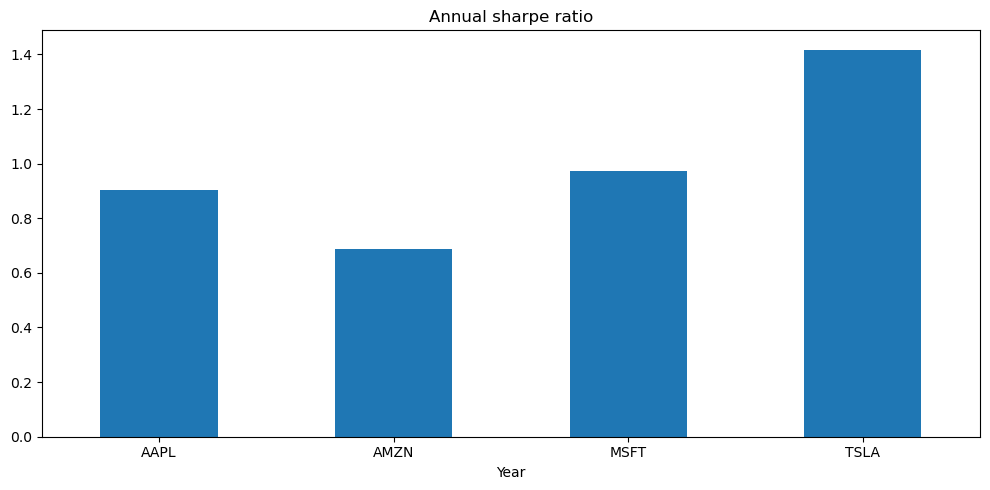

Portfolio Annual Return (geometric): 0.42127159595602715
Portfolio Annual Volatility: 0.3382867976972361
Portfolio Sharpe Ratio: 1.245309006510688
           Ann. Return  Ann. Volatility  Sharpe
Ticker                                         
AAPL             0.293            0.324   0.903
AMZN             0.247            0.360   0.686
MSFT             0.292            0.301   0.972
TSLA             0.958            0.676   1.417
Portfolio        0.421            0.338   1.245


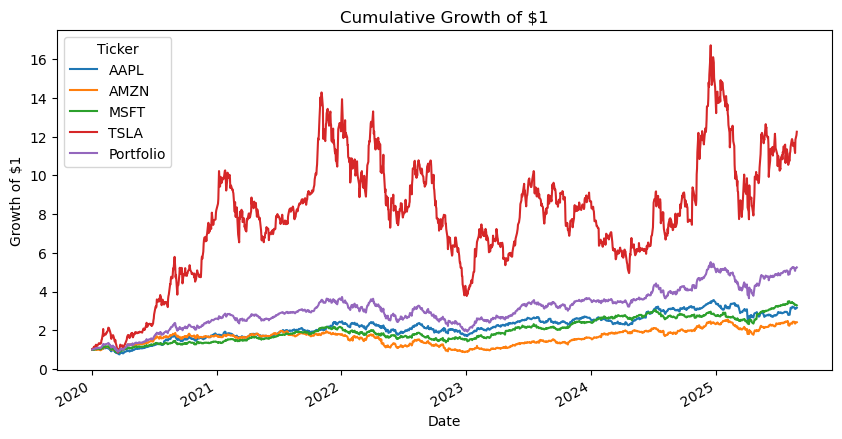

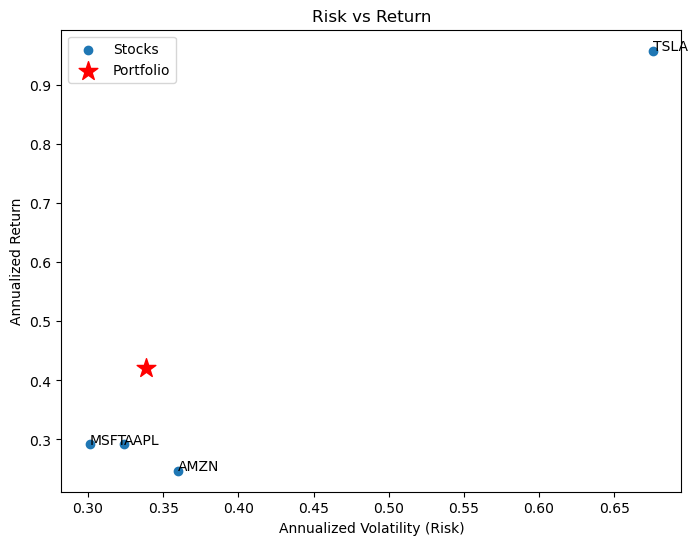

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

ticker = ["AAPL", "MSFT", "TSLA", "AMZN"]
start = "2020-01-01"

prices = yf.download(ticker, start=start, auto_adjust=True, progress=False)["Close"].dropna()

#daily % return
rets = prices.pct_change().dropna()

#Annual Return
geo_ann_return = (1 + rets.mean()) ** 252 - 1
print("\nAnnualized Return (geometric):")
print(geo_ann_return)

#Annual volatility
ann_volatility = (rets.std() * np.sqrt(252)).round(3)
print("\nAnnualized Volatility:")
print(ann_volatility)

# Annual sharpe ratio
ann_sharpe = geo_ann_return / ann_volatility
ax = ann_sharpe.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Annual sharpe ratio")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

#Portfolio annualized return
# 1. equal weights
n = len(rets.columns)
weights = np.repeat(1/n, n)

# 2. Portfolio daily returns (Series)
port_daily_rets = rets.dot(weights)

port_ann_return = (1 + port_daily_rets.mean())**252 - 1
print("Portfolio Annual Return (geometric):", port_ann_return)

# Portfolio annual volatility
cov_annual = rets.cov() * 252
port_ann_vol = np.sqrt(weights @ cov_annual.values @ weights)
print("Portfolio Annual Volatility:", port_ann_vol)

# Portfolio Sharpe
port_sharpe = port_ann_return / port_ann_vol
print("Portfolio Sharpe Ratio:", port_sharpe)

#Summary
summary = pd.DataFrame({
    "Ann. Return": geo_ann_return,
    "Ann. Volatility": ann_volatility,
    "Sharpe": geo_ann_return / ann_volatility
})

summary.loc["Portfolio"] = [port_ann_return, port_ann_vol, port_sharpe]

print(summary.round(3))

#Graph (Cumulative Growth of $1)
cum_stocks = (1 + rets).cumprod()
cum_port = (1 + port_daily_rets).cumprod()
plot_df = cum_stocks.assign(Portfolio=cum_port)

ax = plot_df.plot(figsize=(10,5))
ax.set_title("Cumulative Growth of $1")
ax.set_ylabel("Growth of $1")
plt.show()

# Graph (Risk vs Return Scatter)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(ann_volatility, geo_ann_return, label="Stocks")
ax.scatter(port_ann_vol, port_ann_return, color="red", marker="*", s=200, label="Portfolio")

for ticker in rets.columns:
    ax.text(ann_volatility[ticker], geo_ann_return[ticker], ticker)

ax.set_xlabel("Annualized Volatility (Risk)")
ax.set_ylabel("Annualized Return")
ax.set_title("Risk vs Return")
ax.legend()
plt.show()